In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('duckduck_process_info.csv')
df

,Iter,Time,Process,CPU Usage,Memory Usage,Disk Read Count,Disk Write Count,Disk Read Bytes,Disk Write Bytes
0,1,2025-02-09 09:38:29,DuckDuckGo.exe,17.1,3.116630,58198,21682,68786344,75824630
1,1,2025-02-09 09:38:39,DuckDuckGo.exe,0.3,3.289714,58227,21694,68938676,75835112
2,1,2025-02-09 09:38:49,DuckDuckGo.exe,8.1,3.391010,59504,22401,69524084,80545998
3,1,2025-02-09 09:38:59,DuckDuckGo.exe,18.4,3.563340,62024,23616,71031528,88643579
4,1,2025-02-09 09:39:09,DuckDuckGo.exe,13.1,3.387458,65427,24552,76738922,89020690
...,...,...,...,...,...,...,...,...,...
2786,5,2025-05-03 15:24:15,chrome.exe,0.0,0.426713,100927,57759,290572840,11901104
2787,5,2025-05-03 15:24:25,chrome.exe,0.0,0.426713,100950,57771,290577136,11902688
2788,5,2025-05-03 15:24:35,chrome.exe,0.0,0.426738,100969,57784,290581672,11904144
2789,5,2025-05-03 15:24:45,chrome.exe,0.0,0.426786,100984,57792,290583272,11905472


In [15]:
#Split into 2 dataframes based on what process was monitored, and when it was monitored

#Do a deep copy so we can modify slices of DataFrames
feb_v_may = df[(df['Iter'] == 1) | (df['Iter'] == 4)].copy()
duck_v_chrome = df[(df['Iter'] == 4) | (df['Iter'] == 5)].copy()

In [37]:
#Add a formatted column for Time Reported for Pretty Printing
feb_v_may['Time Recorded'] = df['Iter'].apply(lambda x: "February" if x == 1 else "May")
feb_v_may.dropna(axis=1,inplace=True)
feb_v_may = feb_v_may[feb_v_may['CPU Usage'] >= 0]

In [62]:
def plot_metrics(df, split_by, title):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    # CPU Usage subplot
    sns.histplot(data=df, x='CPU Usage', hue=split_by, stat='probability', ax=axes[0, 0], log_scale=True, multiple='dodge')
    axes[0, 0].set_title('CPU Usage')
    axes[0, 0].set_xlabel('CPU Usage (%)')
    axes[0, 0].set_ylabel('Relative Frequency')

    # Memory Usage subplot
    sns.histplot(data=df, x='Memory Usage', hue=split_by, stat='probability', ax=axes[0, 1], kde=True, multiple='dodge')
    axes[0, 1].set_title('Memory Usage')
    axes[0, 1].set_xlabel('Memory Usage (%)')
    axes[0, 1].set_ylabel('Relative Frequency')

    # Disk Read Bytes subplot
    sns.histplot(data=df, x='Disk Read Bytes', hue=split_by, stat='probability', ax=axes[1, 0], kde=True, log_scale=True, multiple='dodge')
    axes[1, 0].set_title('Disk Read Bytes')
    axes[1, 0].set_xlabel('Disk Read Bytes (Log Scale)')
    axes[1, 0].set_ylabel('Relative Frequency')

    # Disk Write Bytes subplot
    sns.histplot(data=df, x='Disk Write Bytes', hue=split_by, stat='probability', ax=axes[1, 1], kde=True, log_scale=True, multiple='dodge')
    axes[1, 1].set_title('Disk Write Bytes')
    axes[1, 1].set_xlabel('Disk Write Bytes (Log Scale)')
    axes[1, 1].set_ylabel('Relative Frequency')

    # Set global title
    fig.suptitle(title, fontsize=20)

    # Adjust layout to make space for the global title
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(f'{title}.png')
    plt.show()


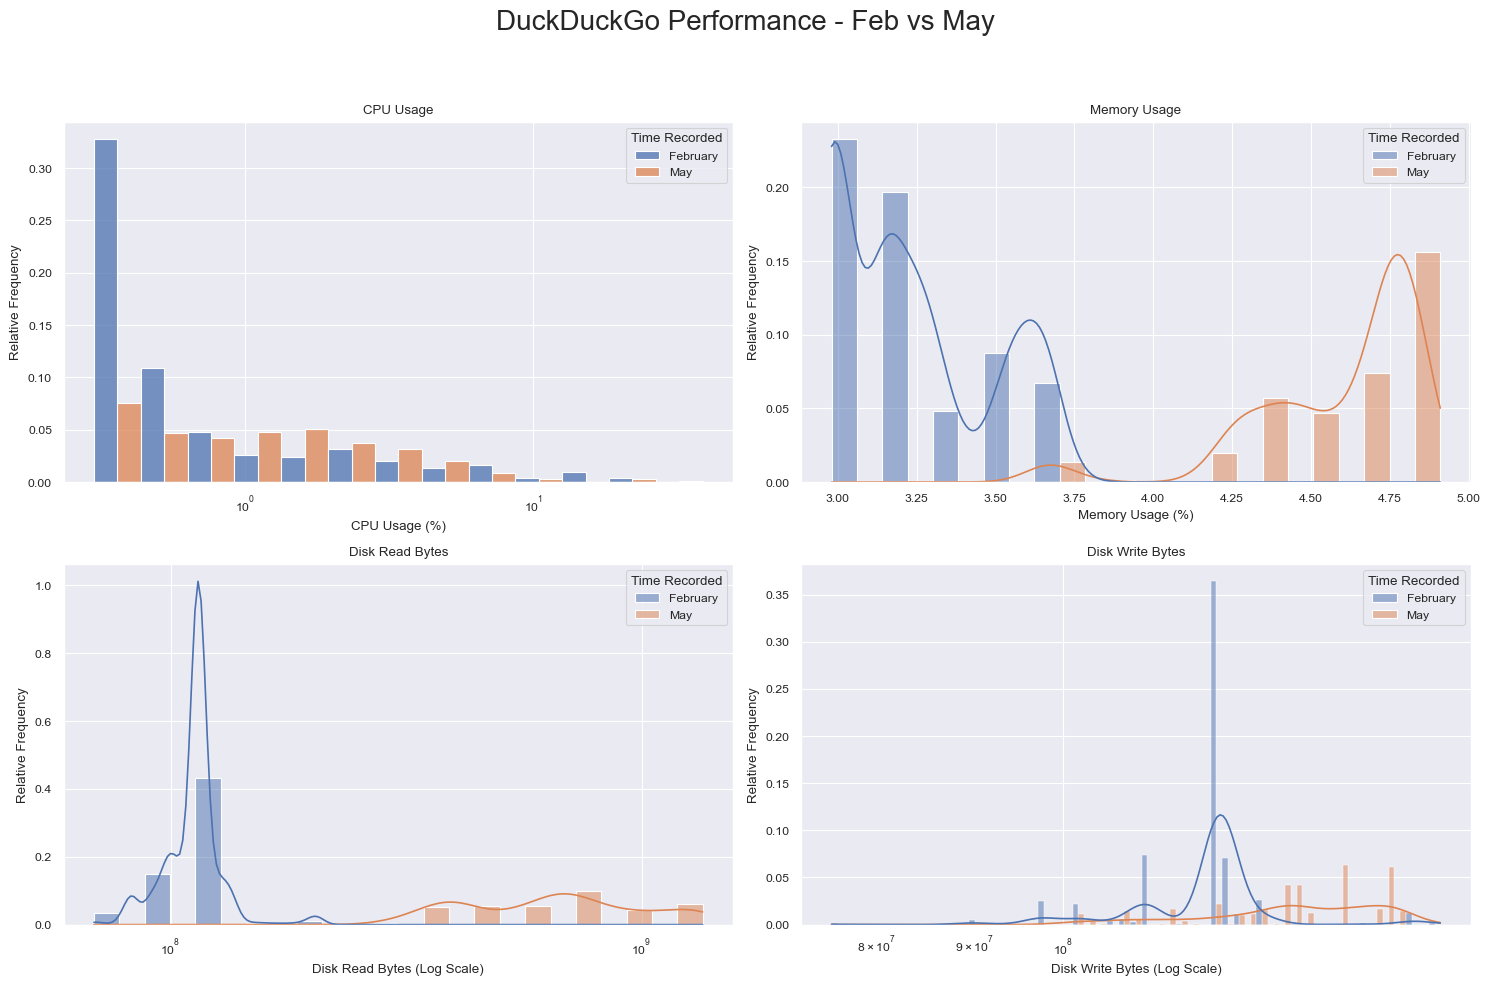

In [63]:
plot_metrics(feb_v_may,split_by="Time Recorded",title='DuckDuckGo Performance - Feb vs May')

In [68]:
#Slight tweaks to the Chrome (this could be vectorized, but speed isn't that important)
def fix_str(s):
    app_name = s.split(".exe")[0]
    return app_name[0].upper() + app_name[1:]

duck_v_chrome['Web Browser'] = df['Process'].apply(fix_str)

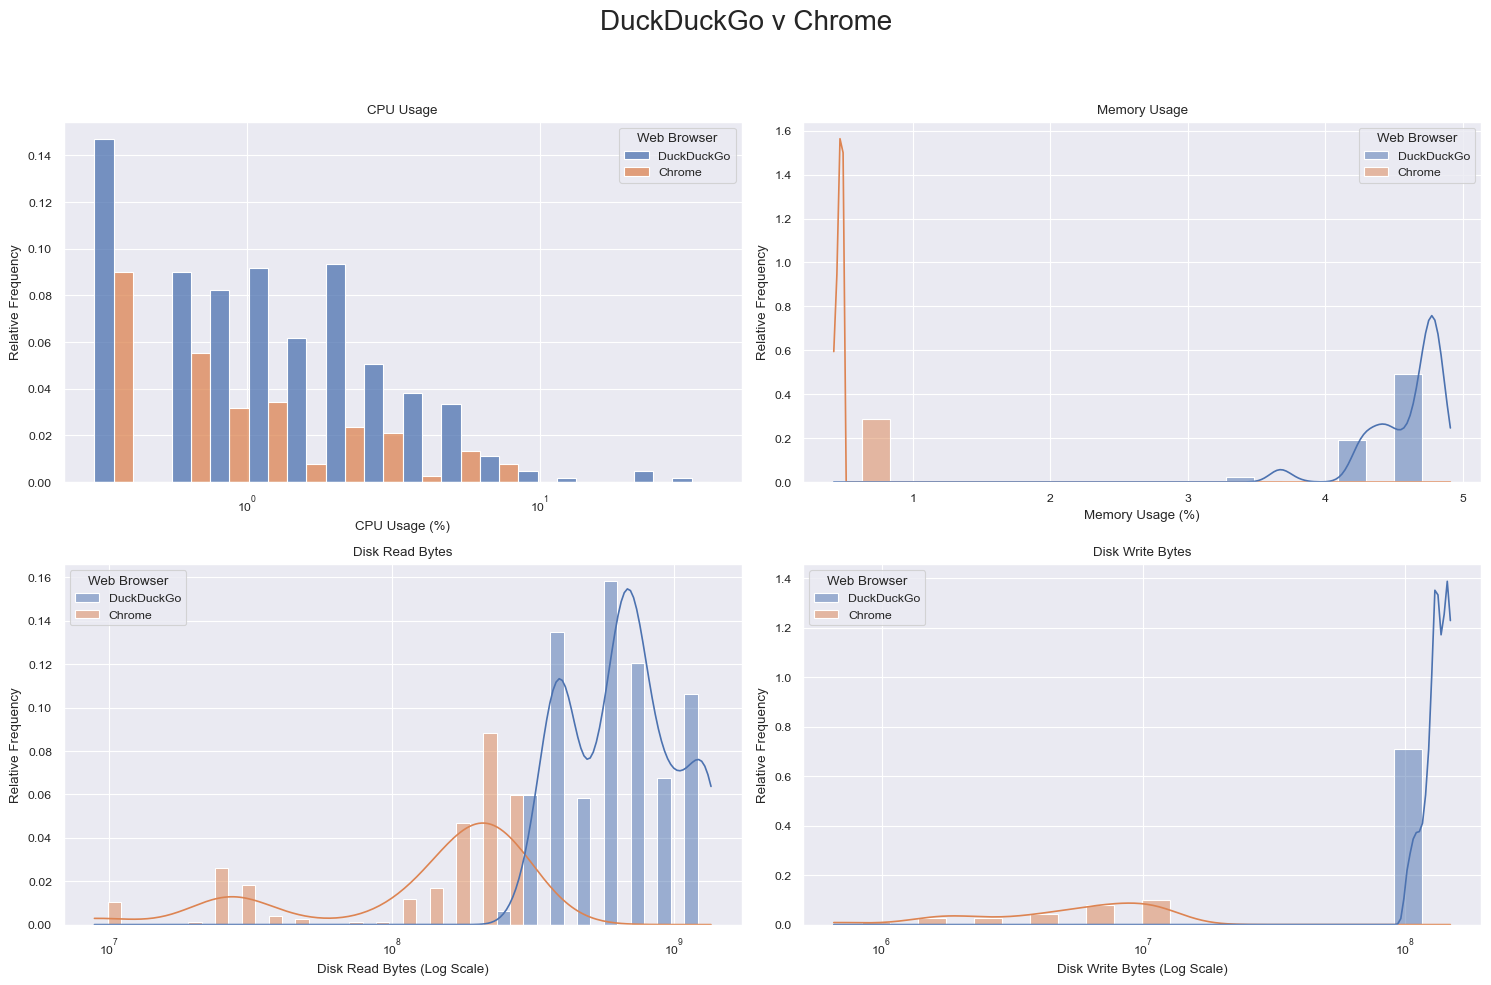

In [69]:
plot_metrics(duck_v_chrome,"Web Browser","DuckDuckGo v Chrome")